<a href="https://colab.research.google.com/github/prajapativipul-pv/GTU_Edunet_internship/blob/main/day7_13_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows
    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2      

/tmp/ipykernel_840/1891139014.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


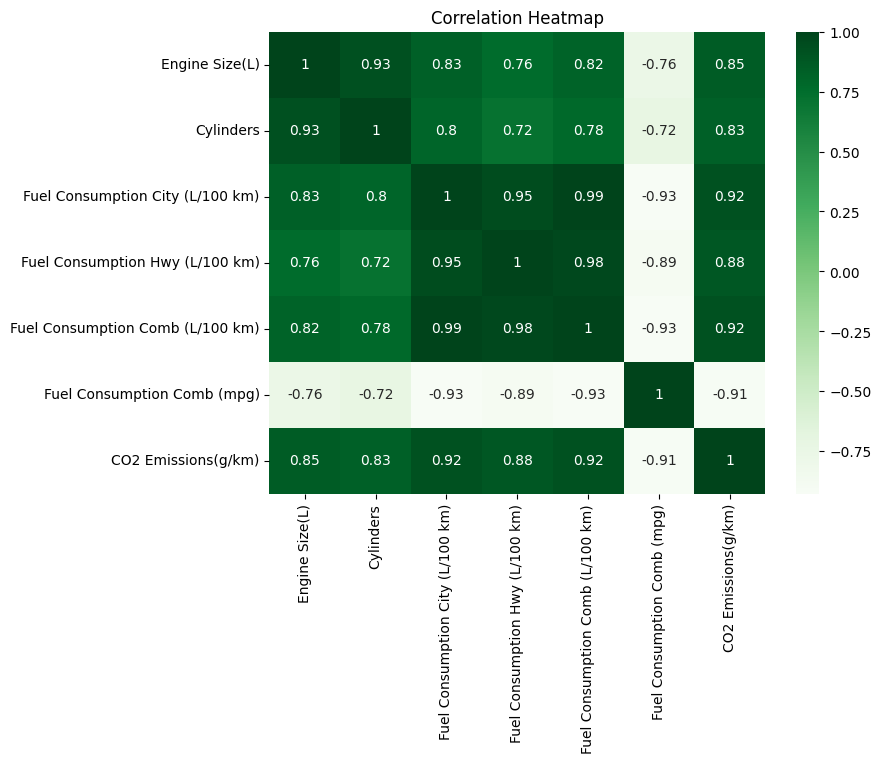

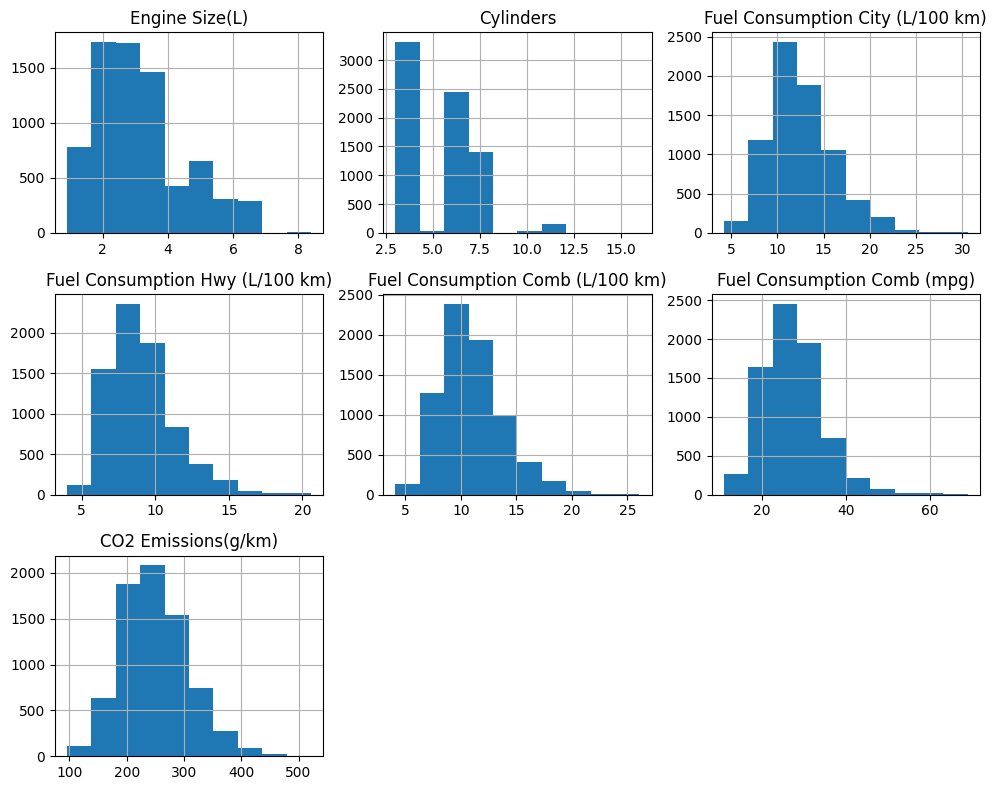

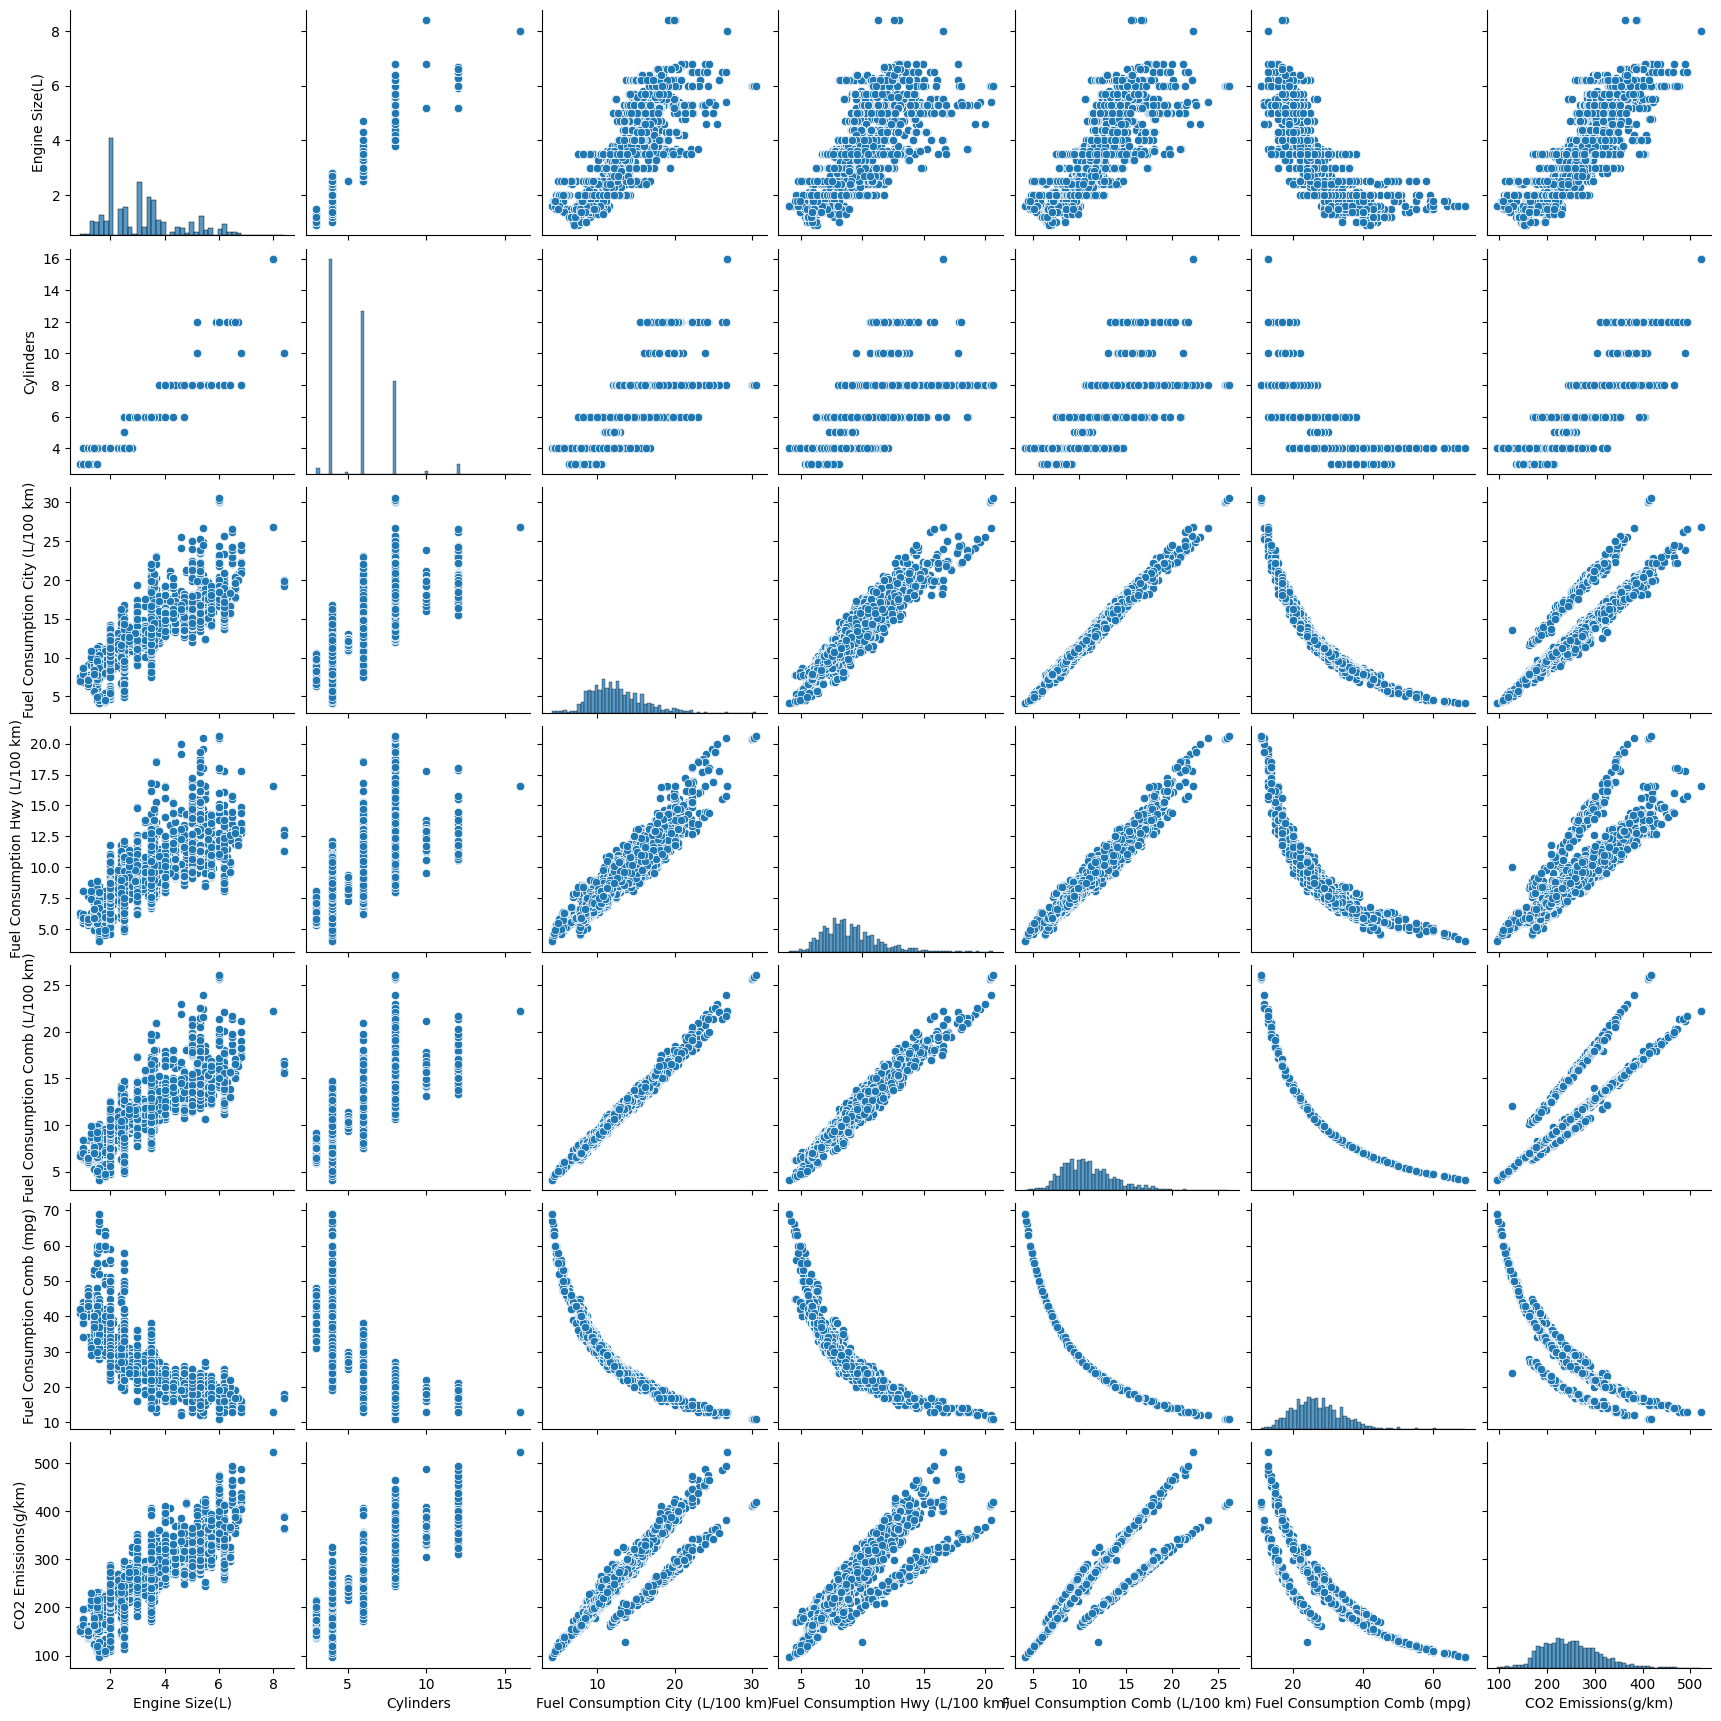

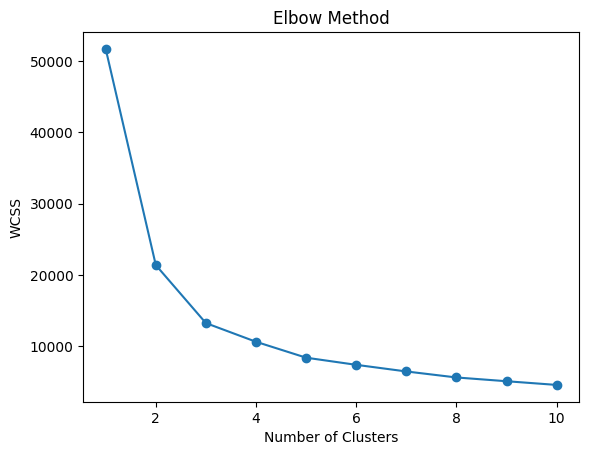


Cluster Counts
Cluster
1    2903
0    2809
2    1673
Name: count, dtype: int64

Silhouette Score = 0.4535750086725096


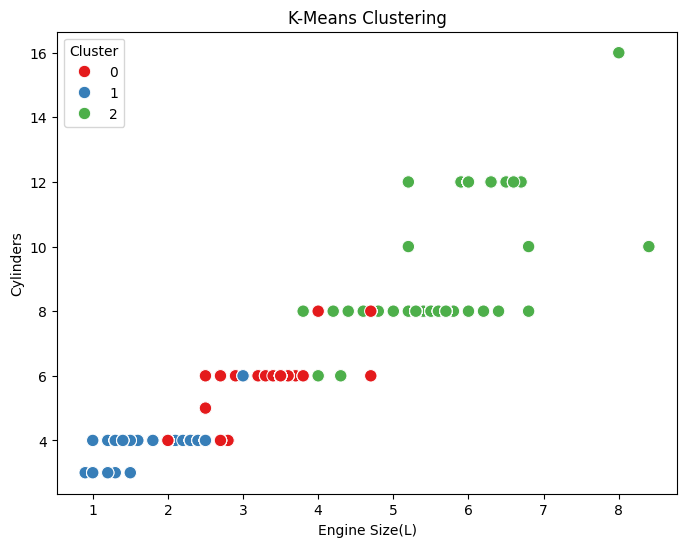

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Dataset

df = pd.read_csv("CO2_Emissions.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Handle Missing Values

# Fill numerical missing values with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Drop remaining missing values if any
df.dropna(inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# Basic Analysis
print("\nStatistical Summary")
print(df.describe())

# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Greens")
plt.title("Correlation Heatmap")
plt.show()

# Histogram

df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# Pairplot

sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

# Select Numerical Features

X = df.select_dtypes(include=np.number)

# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method

wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i,
                   random_state=42,
                   n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Apply K-Means

kmeans = KMeans(n_clusters=3,
                random_state=42,
                n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("\nCluster Counts")
print(df["Cluster"].value_counts())

# Evaluation

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score =", score)

# Cluster Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X.iloc[:,0],
    y=X.iloc[:,1],
    hue=df["Cluster"],
    palette="Set1",
    s=80
)

plt.title("K-Means Clustering")
plt.show()
